In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import itertools
from scipy import stats
from ephys_utils import (
    test_interaction_pvalues,
    plot_significance_bars_shifted,
    process_df_state,
)
import warnings

warnings.filterwarnings("ignore")

In [2]:
def preprocess_plot(
    df, cat_name, name, palette, order, plotting=False, identifier=None
):
    ls = [
        "Cm(pF)",
        "Firing_freq_(Hz)_I0",
        "Instant_freq_(Hz)",
        "isi_(ms)",
        "CaT",
        "Sag (mV)",
        "AP_ampl",
        "AP_halfwidth",
        "AP_time_to_peak",
        "area(mV_ms)",
        "rheobase_at_-60mV_(pA)",
        "AHP_(mV)",
        "Vm",
        "RI (MΩ)",
        "sPSC_frequency",
        "sPSC_Amplitude(pA)",
        "sPSCs_Rise time",
        "sPSCs (decay)",
    ]

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in [
            "isi_(ms)",
            "AP_ampl",
            "AP_halfwidth",
            "AP_time_to_peak",
            "area(mV_ms)",
            "AHP_(mV)",
        ]:
            param_df = df[df.I_zero != "silent"]

        else:
            param_df = df

        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)
                print(param_df.dropna(subset=column)[cat_name].value_counts())
                print(
                    param_df.dropna(subset=column)
                    .groupby(cat_name)["ID_mouse"]
                    .nunique()
                )
                stat, p = stats.mannwhitneyu(
                    param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                    param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                )

                print(column, combo, stat, p)

        except ValueError:

            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())

                sns.set(rc={"figure.figsize": (2, 3)})
                sns.set(font_scale=2.5)
                sns.set_style("ticks")

                ax = sns.boxplot(
                    x=cat_name,
                    y=column,
                    data=param_df,
                    order=order,
                    palette=palette,
                    saturation=8,
                    linewidth=1.7,
                    showfliers=False,
                    boxprops=dict(alpha=0.5),
                )
                ax = sns.stripplot(
                    x=cat_name,
                    y=column,
                    data=param_df,
                    order=order,
                    jitter=True,
                    dodge=False,
                    marker="o",
                    size=7,
                    linewidth=1,
                    edgecolor="gray",
                    palette=palette,
                    alpha=0.5,
                    zorder=0,
                )
                ax.set_xlabel("")
                plt.xticks(rotation=45)
                # ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-',  'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(4))
                plt.ylabel(column.replace("_", " "))

                sns.despine()

                plt.savefig(
                    f"output_figures/{identifier}_{column}.pdf",
                    dpi=300,
                    bbox_inches="tight",
                    transparent=True,
                )
                # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/{column}_sampled_{identifier}.pdf',
                #     dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass


def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins=True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]

    print(stats.fisher_exact(prop))

    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)

    prop = prop[cols]
    prop = prop.reset_index()
    return prop

pre_post_state
Pre     19
Post    19
Name: count, dtype: int64
pre_post_state
Post    7
Pre     8
Name: ID_mouse, dtype: int64
Cm(pF) ('Pre', 'Post') 161.0 0.5790997419539189
pre_post_state
Post    40.410829
Pre     37.385992
Name: Cm(pF), dtype: float64


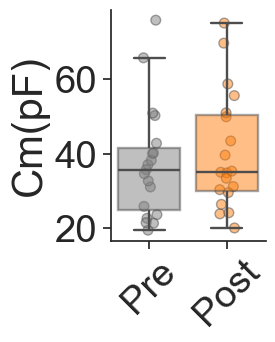

pre_post_state
Pre     132
Post     25
Name: count, dtype: int64
pre_post_state
Post     9
Pre     43
Name: ID_mouse, dtype: int64
Firing_freq_(Hz)_I0 ('Pre', 'Post') 2069.0 0.04164018106258195
pre_post_state
Post    0.517200
Pre     1.770379
Name: Firing_freq_(Hz)_I0, dtype: float64


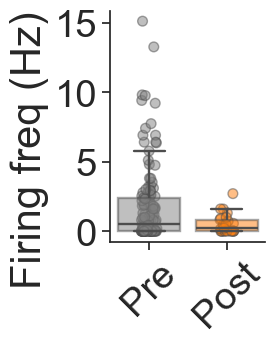

pre_post_state
Pre     132
Post     25
Name: count, dtype: int64
pre_post_state
Post     9
Pre     43
Name: ID_mouse, dtype: int64
Instant_freq_(Hz) ('Pre', 'Post') 2099.5 0.028848521020518523
pre_post_state
Post    0.807600
Pre     2.143485
Name: Instant_freq_(Hz), dtype: float64


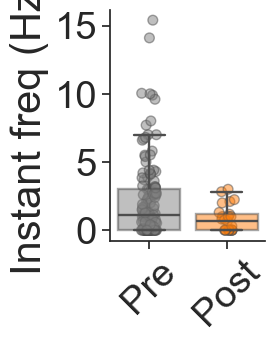

pre_post_state
Pre     94
Post    14
Name: count, dtype: int64
pre_post_state
Post     8
Pre     40
Name: ID_mouse, dtype: int64
isi_(ms) ('Pre', 'Post') 502.0 0.1549490176318414
pre_post_state
Post    1866.371429
Pre     3999.578723
Name: isi_(ms), dtype: float64


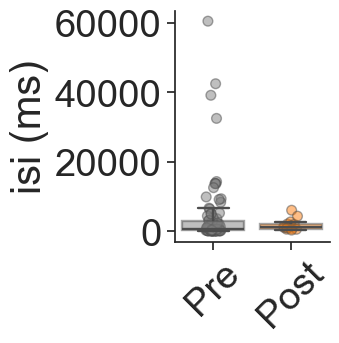

pre_post_state
Pre     108
Post     24
Name: count, dtype: int64
pre_post_state
Post     9
Pre     39
Name: ID_mouse, dtype: int64
CaT ('Pre', 'Post') 1370.0 0.6209380971552163
pre_post_state
Post    4.950833
Pre     5.926481
Name: CaT, dtype: float64


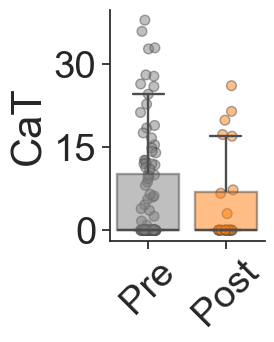

pre_post_state
Pre     108
Post     24
Name: count, dtype: int64
pre_post_state
Post     9
Pre     39
Name: ID_mouse, dtype: int64
Sag (mV) ('Pre', 'Post') 1633.5 0.04474162546436981
pre_post_state
Post    3.750417
Pre     7.146852
Name: Sag (mV), dtype: float64


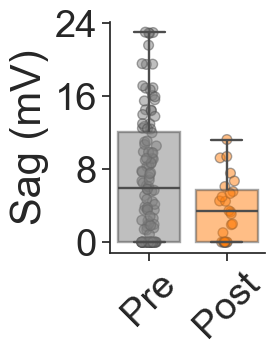

pre_post_state
Pre     79
Post    14
Name: count, dtype: int64
pre_post_state
Post     8
Pre     39
Name: ID_mouse, dtype: int64
AP_ampl ('Pre', 'Post') 461.0 0.32557980161770383
pre_post_state
Post    91.063571
Pre     86.062152
Name: AP_ampl, dtype: float64


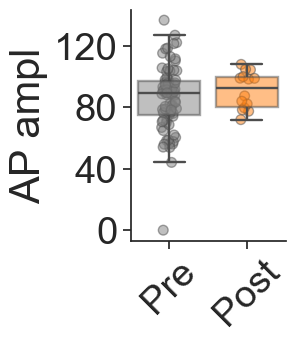

pre_post_state
Pre     77
Post    14
Name: count, dtype: int64
pre_post_state
Post     8
Pre     39
Name: ID_mouse, dtype: int64
AP_halfwidth ('Pre', 'Post') 525.0 0.8819155564485519
pre_post_state
Post    3.222143
Pre     2.942468
Name: AP_halfwidth, dtype: float64


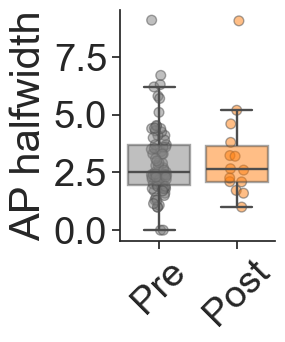

pre_post_state
Pre     78
Post    14
Name: count, dtype: int64
pre_post_state
Post     8
Pre     39
Name: ID_mouse, dtype: int64
AP_time_to_peak ('Pre', 'Post') 641.0 0.3039706586929216
pre_post_state
Post    2.285
Pre     2.615
Name: AP_time_to_peak, dtype: float64


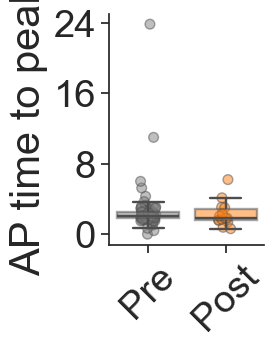

pre_post_state
Pre     78
Post    14
Name: count, dtype: int64
pre_post_state
Post     8
Pre     39
Name: ID_mouse, dtype: int64
area(mV_ms) ('Pre', 'Post') 504.5 0.6558270140698104
pre_post_state
Post    287.642857
Pre     278.371795
Name: area(mV_ms), dtype: float64


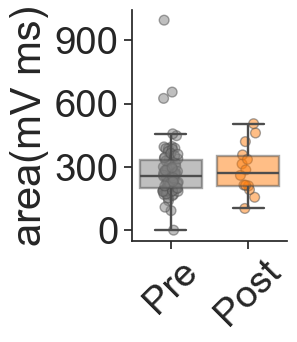

pre_post_state
Pre     84
Post    24
Name: count, dtype: int64
pre_post_state
Post     9
Pre     30
Name: ID_mouse, dtype: int64
rheobase_at_-60mV_(pA) ('Pre', 'Post') 905.0 0.44805942828278433
pre_post_state
Post    24.041667
Pre     16.238095
Name: rheobase_at_-60mV_(pA), dtype: float64


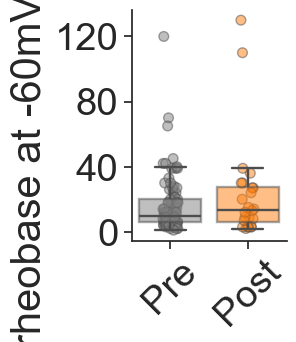

pre_post_state
Pre     78
Post    14
Name: count, dtype: int64
pre_post_state
Post     8
Pre     39
Name: ID_mouse, dtype: int64
AHP_(mV) ('Pre', 'Post') 651.0 0.25596108546269625
pre_post_state
Post   -53.819286
Pre    -50.008205
Name: AHP_(mV), dtype: float64


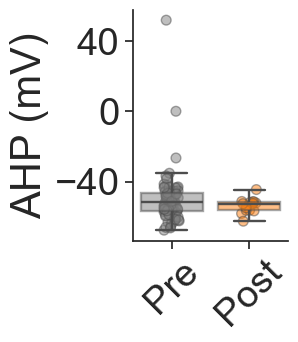

pre_post_state
Pre     131
Post     25
Name: count, dtype: int64
pre_post_state
Post     9
Pre     43
Name: ID_mouse, dtype: int64
Vm ('Pre', 'Post') 1789.0 0.46570943008498533
pre_post_state
Post   -48.172121
Pre    -46.233527
Name: Vm, dtype: float64


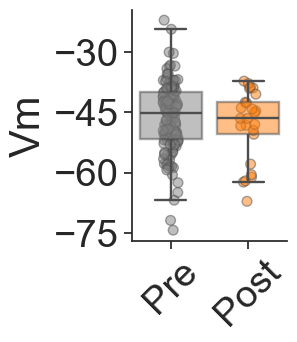

pre_post_state
Pre     109
Post     24
Name: count, dtype: int64
pre_post_state
Post     9
Pre     39
Name: ID_mouse, dtype: int64
RI (MΩ) ('Pre', 'Post') 1069.0 0.16288651799802645
pre_post_state
Post    744.169135
Pre     672.075505
Name: RI (MΩ), dtype: float64


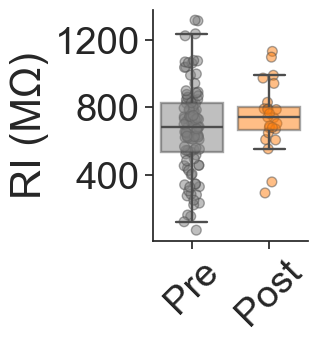

pre_post_state
Pre     50
Post    26
Name: count, dtype: int64
pre_post_state
Post     9
Pre     23
Name: ID_mouse, dtype: int64
sPSC_frequency ('Pre', 'Post') 617.5 0.7260594719247089
pre_post_state
Post    2.02613
Pre     1.71229
Name: sPSC_frequency, dtype: float64


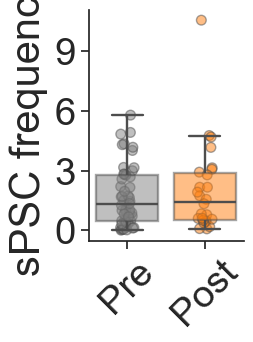

pre_post_state
Pre     50
Post    26
Name: count, dtype: int64
pre_post_state
Post     9
Pre     23
Name: ID_mouse, dtype: int64
sPSC_Amplitude(pA) ('Pre', 'Post') 698.5 0.5991827708223081
pre_post_state
Post    11.695165
Pre     12.360542
Name: sPSC_Amplitude(pA), dtype: float64


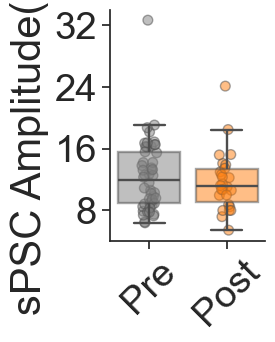

pre_post_state
Pre     47
Post    26
Name: count, dtype: int64
pre_post_state
Post     9
Pre     20
Name: ID_mouse, dtype: int64
sPSCs_Rise time ('Pre', 'Post') 612.0 0.99536721866994
pre_post_state
Post    1.142308
Pre     1.276596
Name: sPSCs_Rise time, dtype: float64


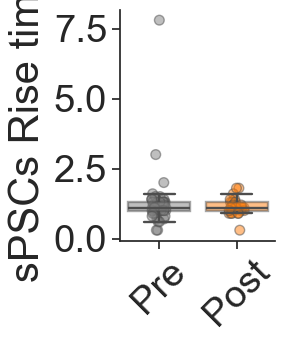

pre_post_state
Pre     43
Post    25
Name: count, dtype: int64
pre_post_state
Post     9
Pre     19
Name: ID_mouse, dtype: int64
sPSCs (decay) ('Pre', 'Post') 559.0 0.7893749944014009
pre_post_state
Post     9.966788
Pre     14.063905
Name: sPSCs (decay), dtype: float64


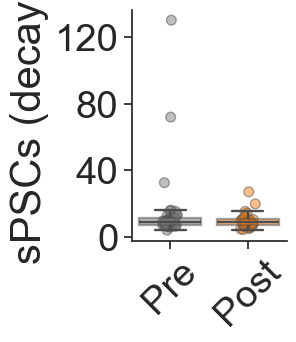

In [3]:
filter_cat = ["Pre", "Agg+", "Agg-"]

ephys = pd.read_csv("sampled_ephys_data_after_adding_BJ.csv")
ephys["pre_post_state"] = ephys["Behaviour_6hFD"].apply(
    lambda x: "Pre" if x == "Pre" else "Post"
)
ephys.rename(
    columns={
        "Input_Resistance": "RI (MΩ)",
        "Ih_at_-120mV": "Sag (mV)",
        "filename": "experiment_day",
    },
    inplace=True,
)


filtered_ephys = ephys[(ephys.Behaviour_6hFD.isin(filter_cat))]
#   & (~ephys.experiment_day.str.contains('2025'))] # just take rachida's data#


# filtered_ephys = ephys[(ephys.Behaviour_6hFD.isin(filter_cat)) ]

agg = ephys[ephys.Behaviour_6hFD == "Agg+"]
agg_size = agg.shape[0]
no_agg = ephys[ephys.Behaviour_6hFD == "Agg-"].sample(
    n=int(agg_size * 0.25), random_state=40
)

estrous_samples = pd.concat([agg, no_agg]).estrous_stage
estrous_samples.loc[estrous_samples == "P to E"] = "P"
estrous_samples.loc[estrous_samples == "D to P"] = "D"


# sampled_ephys = pd.concat([filtered_ephys[filtered_ephys.Behaviour_6hFD == 'Pre'], agg, no_agg])


# # 1. Create subset of 'Pre' trials
pre_df = filtered_ephys[filtered_ephys.Behaviour_6hFD == "Pre"]

# 2. Get desired distribution from 'estrous_samples'
target_counts = estrous_samples.value_counts(normalize=True)

# 3. Compute desired sample size
n_pre_samples = pre_df.shape[0]  # or set a fixed number if you want
sample_counts = (target_counts * n_pre_samples).astype(
    int
) // 1.5  # keep it to the maximum to make sure that estrous distribution is roughly the same

# 4. Sample from pre_df stratified by estrous_stage
sampled_pre = (
    pre_df.groupby("estrous_stage")
    .apply(
        lambda x: x.sample(
            n=min(sample_counts.astype(int).get(x.name, 20), len(x)), random_state=42
        )
    )
    .reset_index(drop=True)
)

# 5. Combine all into your final sampled dataset
sampled_ephys = pd.concat([sampled_pre, agg, no_agg])


preprocess_plot(
    sampled_ephys,
    "pre_post_state",
    "pan",
    palette=["Gray", "Tab:orange"],
    order=["Pre", "Post"],
    identifier=None,
    plotting=True,
)

pre_post_state  estrous_stage
Pre             D                47
Name: count, dtype: int64
pre_post_state
Post    6
Pre     1
Name: count, dtype: int64
pre_post_state
Post    2
Pre     1
Name: ID_mouse, dtype: int64
Cm(pF) ('Pre', 'Post') 1.0 0.5714285714285714
pre_post_state
Post    49.056072
Pre     31.119800
Name: Cm(pF), dtype: float64


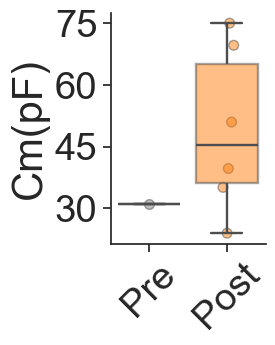

pre_post_state
Pre     47
Post    10
Name: count, dtype: int64
pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64
Firing_freq_(Hz)_I0 ('Pre', 'Post') 297.0 0.1885367461452978
pre_post_state
Post    0.472000
Pre     1.923191
Name: Firing_freq_(Hz)_I0, dtype: float64


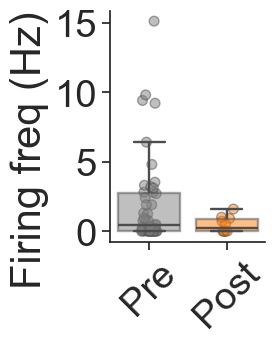

pre_post_state
Pre     47
Post    10
Name: count, dtype: int64
pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64
Instant_freq_(Hz) ('Pre', 'Post') 303.0 0.14896956434945108
pre_post_state
Post    0.82200
Pre     2.38383
Name: Instant_freq_(Hz), dtype: float64


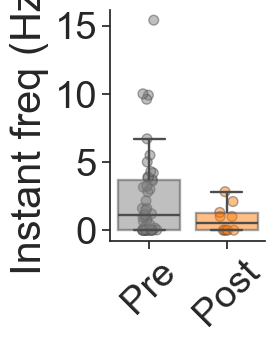

pre_post_state
Pre     32
Post     5
Name: count, dtype: int64
pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64
isi_(ms) ('Pre', 'Post') 63.0 0.4752040046157693
pre_post_state
Post    1228.00000
Pre     3658.65625
Name: isi_(ms), dtype: float64


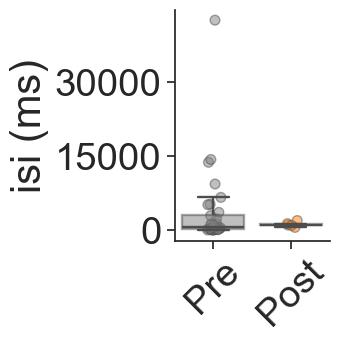

pre_post_state
Pre     38
Post     9
Name: count, dtype: int64
pre_post_state
Post     3
Pre     11
Name: ID_mouse, dtype: int64
CaT ('Pre', 'Post') 222.0 0.14621669824075917
pre_post_state
Post    4.277778
Pre     8.404474
Name: CaT, dtype: float64


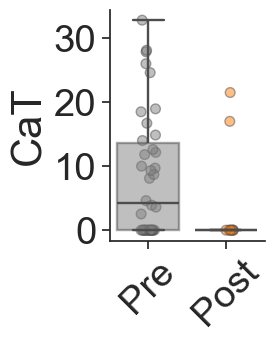

pre_post_state
Pre     38
Post     9
Name: count, dtype: int64
pre_post_state
Post     3
Pre     11
Name: ID_mouse, dtype: int64
Sag (mV) ('Pre', 'Post') 261.5 0.014484744329157941
pre_post_state
Post    2.766667
Pre     8.638158
Name: Sag (mV), dtype: float64


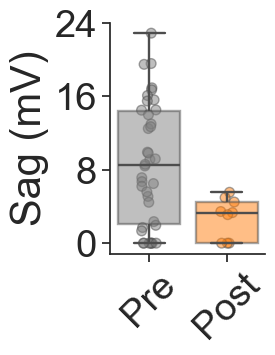

pre_post_state
Pre     27
Post     5
Name: count, dtype: int64
pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64
AP_ampl ('Pre', 'Post') 57.0 0.6037280605420001
pre_post_state
Post    91.680000
Pre     85.569259
Name: AP_ampl, dtype: float64


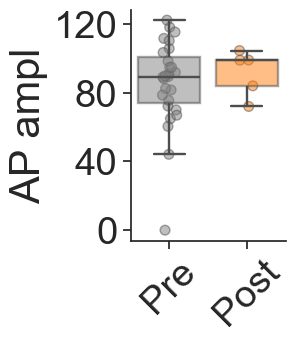

pre_post_state
Pre     25
Post     5
Name: count, dtype: int64
pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64
AP_halfwidth ('Pre', 'Post') 75.0 0.5038916647600298
pre_post_state
Post    2.3120
Pre     2.5988
Name: AP_halfwidth, dtype: float64


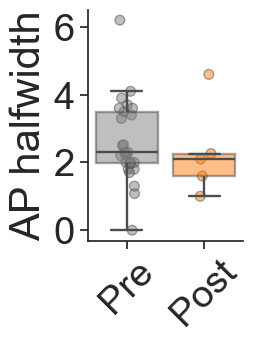

pre_post_state
Pre     26
Post     5
Name: count, dtype: int64
pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64
AP_time_to_peak ('Pre', 'Post') 94.0 0.12546299411563797
pre_post_state
Post    1.744000
Pre     3.268077
Name: AP_time_to_peak, dtype: float64


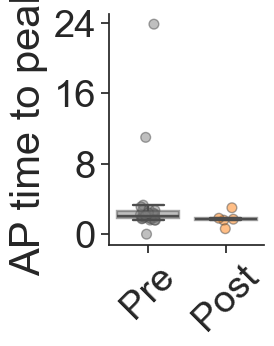

pre_post_state
Pre     26
Post     5
Name: count, dtype: int64
pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64
area(mV_ms) ('Pre', 'Post') 76.0 0.5837526705157405
pre_post_state
Post    236.00
Pre     295.05
Name: area(mV_ms), dtype: float64


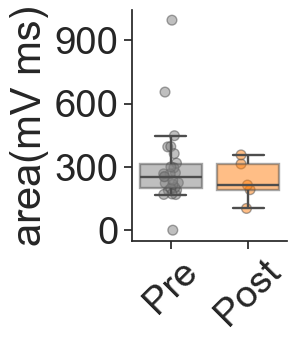

pre_post_state
Pre     30
Post     9
Name: count, dtype: int64
pre_post_state
Post    3
Pre     8
Name: ID_mouse, dtype: int64
rheobase_at_-60mV_(pA) ('Pre', 'Post') 104.5 0.3160089958765263
pre_post_state
Post    18.555556
Pre     14.966667
Name: rheobase_at_-60mV_(pA), dtype: float64


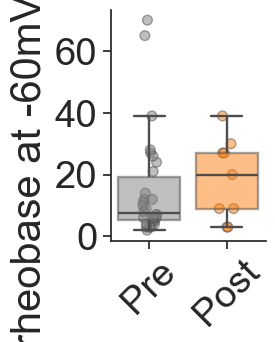

pre_post_state
Pre     26
Post     5
Name: count, dtype: int64
pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64
AHP_(mV) ('Pre', 'Post') 71.0 0.7676448268235513
pre_post_state
Post   -54.020000
Pre    -50.615769
Name: AHP_(mV), dtype: float64


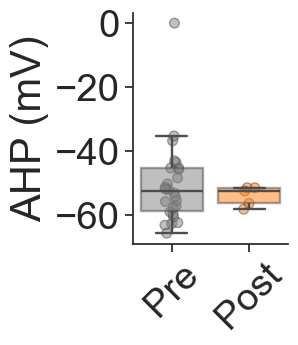

pre_post_state
Pre     46
Post    10
Name: count, dtype: int64
pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64
Vm ('Pre', 'Post') 253.0 0.6302710575645317
pre_post_state
Post   -48.594431
Pre    -46.988840
Name: Vm, dtype: float64


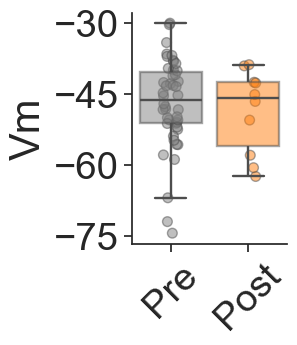

pre_post_state
Pre     38
Post     9
Name: count, dtype: int64
pre_post_state
Post     3
Pre     11
Name: ID_mouse, dtype: int64
RI (MΩ) ('Pre', 'Post') 93.0 0.036139000451453844
pre_post_state
Post    782.414345
Pre     606.510992
Name: RI (MΩ), dtype: float64


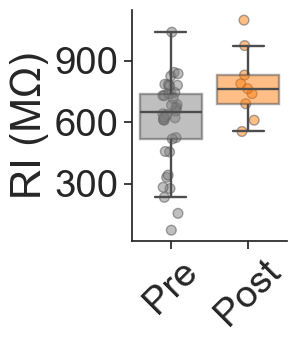

pre_post_state
Post    12
Pre      8
Name: count, dtype: int64
pre_post_state
Post    3
Pre     4
Name: ID_mouse, dtype: int64
sPSC_frequency ('Pre', 'Post') 17.5 0.02058991035319979
pre_post_state
Post    2.634073
Pre     0.631541
Name: sPSC_frequency, dtype: float64


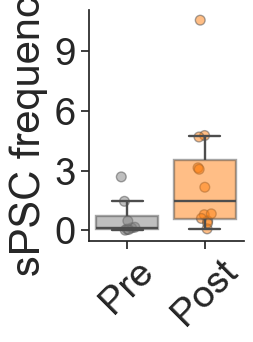

pre_post_state
Post    12
Pre      8
Name: count, dtype: int64
pre_post_state
Post    3
Pre     4
Name: ID_mouse, dtype: int64
sPSC_Amplitude(pA) ('Pre', 'Post') 20.0 0.03142017940779551
pre_post_state
Post    12.604875
Pre      9.036500
Name: sPSC_Amplitude(pA), dtype: float64


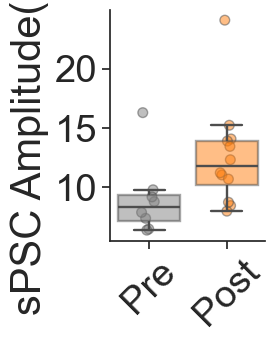

pre_post_state
Post    12
Pre      7
Name: count, dtype: int64
pre_post_state
Post    3
Pre     3
Name: ID_mouse, dtype: int64
sPSCs_Rise time ('Pre', 'Post') 62.0 0.0930984409019887
pre_post_state
Post    1.108333
Pre     2.428571
Name: sPSCs_Rise time, dtype: float64


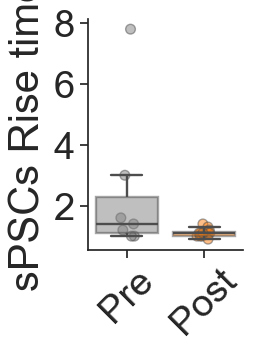

pre_post_state
Post    12
Pre      5
Name: count, dtype: int64
pre_post_state
Post    3
Pre     3
Name: ID_mouse, dtype: int64
sPSCs (decay) ('Pre', 'Post') 29.5 1.0
pre_post_state
Post     9.875917
Pre     10.210000
Name: sPSCs (decay), dtype: float64


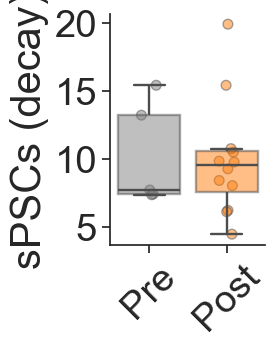

In [4]:
agg = ephys[
    (ephys.Behaviour_6hFD == "Agg+") & (ephys.estrous_stage.isin(["D", "D to P"]))
]
agg.rename(columns={"filename": "experiment_day"}, inplace=True)
agg_size = agg.shape[0]
# no_agg = ephys[(ephys.Behaviour_6hFD == 'Agg-') &
#                (ephys.estrous_stage.isin(['P', 'D to P']))].sample(n = int(agg_size*0.25), random_state = 40)

estrous_samples = agg.estrous_stage
estrous_samples.loc[estrous_samples == "P to E"] = "P"
estrous_samples.loc[estrous_samples == "D to P"] = "D"

sampled_pre = filtered_ephys[
    (filtered_ephys.Behaviour_6hFD == "Pre")
    & (filtered_ephys.estrous_stage.isin(["D", "D to P"]))
]

print(sampled_pre[["pre_post_state", "estrous_stage"]].value_counts())
# 5. Combine all into your final sampled dataset
sampled_ephys_estrous = pd.concat([sampled_pre, agg], ignore_index=True, axis=0)


preprocess_plot(
    sampled_ephys_estrous,
    "pre_post_state",
    "pan",
    palette=["Gray", "Tab:orange"],
    order=["Pre", "Post"],
    identifier="Diestrous",
    plotting=True,
)

estrous_stage
P    12
M    10
Name: count, dtype: int64
Behaviour_6hFD
Agg-    14
Pre      5
Name: count, dtype: int64
Behaviour_6hFD
Agg-    2
Pre     3
Name: ID_mouse, dtype: int64
Cm(pF) ('Pre', 'Agg-') 7.0 0.007223942208462332
Behaviour_6hFD
Agg-    57.305281
Pre     25.365132
Name: Cm(pF), dtype: float64


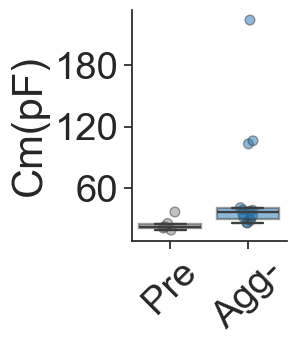

Behaviour_6hFD
Agg-    22
Pre     20
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     14
Name: ID_mouse, dtype: int64
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 190.0 0.45519054308299944
Behaviour_6hFD
Agg-    2.212273
Pre     2.337000
Name: Firing_freq_(Hz)_I0, dtype: float64


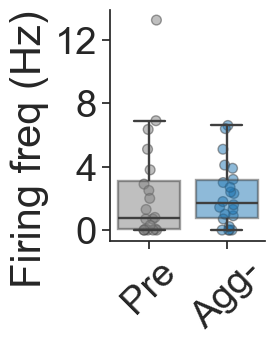

Behaviour_6hFD
Agg-    22
Pre     20
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     14
Name: ID_mouse, dtype: int64
Instant_freq_(Hz) ('Pre', 'Agg-') 211.0 0.8296570352939081
Behaviour_6hFD
Agg-    2.549545
Pre     2.846000
Name: Instant_freq_(Hz), dtype: float64


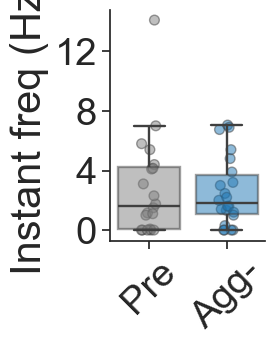

Behaviour_6hFD
Agg-    18
Pre     15
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     10
Name: ID_mouse, dtype: int64
isi_(ms) ('Pre', 'Agg-') 151.0 0.5752041202578282
Behaviour_6hFD
Agg-     748.955556
Pre     2496.906667
Name: isi_(ms), dtype: float64


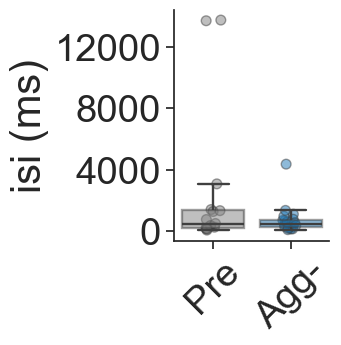

Behaviour_6hFD
Agg-    22
Pre     19
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     12
Name: ID_mouse, dtype: int64
CaT ('Pre', 'Agg-') 171.0 0.2863841485372167
Behaviour_6hFD
Agg-    5.747273
Pre     4.721053
Name: CaT, dtype: float64


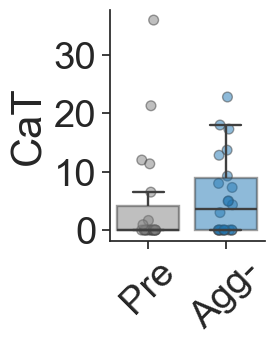

Behaviour_6hFD
Agg-    22
Pre     19
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     12
Name: ID_mouse, dtype: int64
Sag (mV) ('Pre', 'Agg-') 193.5 0.6942142646439171
Behaviour_6hFD
Agg-    7.454091
Pre     6.994211
Name: Sag (mV), dtype: float64


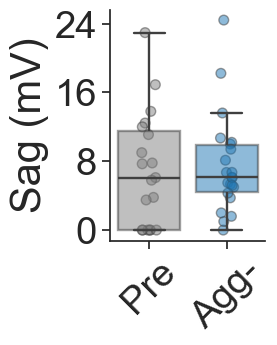

Behaviour_6hFD
Agg-    18
Pre     15
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     10
Name: ID_mouse, dtype: int64
AP_ampl ('Pre', 'Agg-') 111.5 0.405614296434039
Behaviour_6hFD
Agg-    88.562778
Pre     86.880667
Name: AP_ampl, dtype: float64


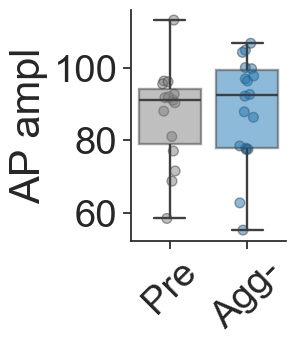

Behaviour_6hFD
Agg-    18
Pre     15
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     10
Name: ID_mouse, dtype: int64
AP_halfwidth ('Pre', 'Agg-') 187.0 0.062341899996699854
Behaviour_6hFD
Agg-    2.132222
Pre     2.979333
Name: AP_halfwidth, dtype: float64


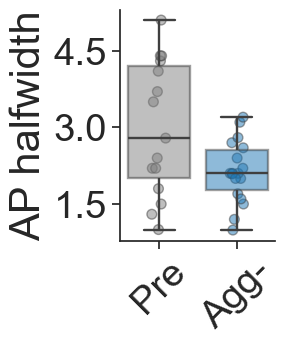

Behaviour_6hFD
Agg-    18
Pre     15
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     10
Name: ID_mouse, dtype: int64
AP_time_to_peak ('Pre', 'Agg-') 172.5 0.17995987656715395
Behaviour_6hFD
Agg-    1.992222
Pre     2.256000
Name: AP_time_to_peak, dtype: float64


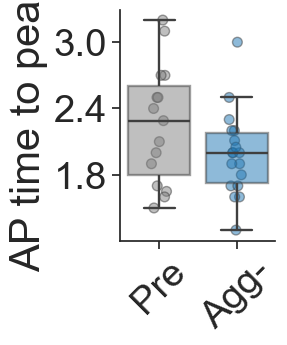

Behaviour_6hFD
Agg-    18
Pre     15
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     10
Name: ID_mouse, dtype: int64
area(mV_ms) ('Pre', 'Agg-') 181.0 0.09995826901598173
Behaviour_6hFD
Agg-    212.050000
Pre     265.733333
Name: area(mV_ms), dtype: float64


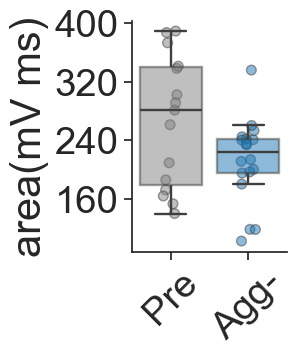

Behaviour_6hFD
Agg-    21
Pre     13
Name: count, dtype: int64
Behaviour_6hFD
Agg-    3
Pre     8
Name: ID_mouse, dtype: int64
rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 109.5 0.34656146063927595
Behaviour_6hFD
Agg-    21.904762
Pre     12.615385
Name: rheobase_at_-60mV_(pA), dtype: float64


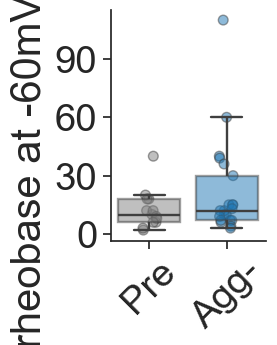

Behaviour_6hFD
Agg-    18
Pre     15
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     10
Name: ID_mouse, dtype: int64
AHP_(mV) ('Pre', 'Agg-') 124.5 0.7176425955941981
Behaviour_6hFD
Agg-   -52.755556
Pre    -53.634000
Name: AHP_(mV), dtype: float64


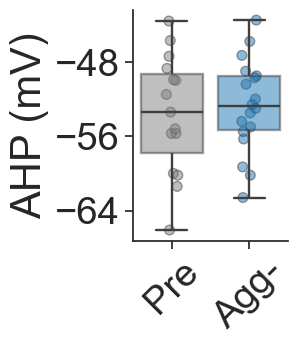

Behaviour_6hFD
Agg-    22
Pre     20
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     14
Name: ID_mouse, dtype: int64
Vm ('Pre', 'Agg-') 213.0 0.8699688801390326
Behaviour_6hFD
Agg-   -45.997810
Pre    -47.323636
Name: Vm, dtype: float64


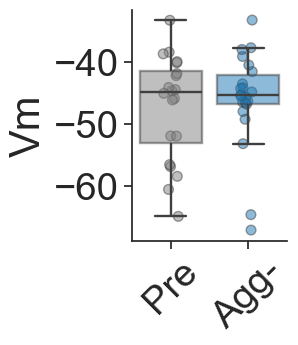

Behaviour_6hFD
Agg-    22
Pre     19
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     12
Name: ID_mouse, dtype: int64
RI (MΩ) ('Pre', 'Agg-') 249.0 0.30174347252746736
Behaviour_6hFD
Agg-    605.318491
Pre     674.300240
Name: RI (MΩ), dtype: float64


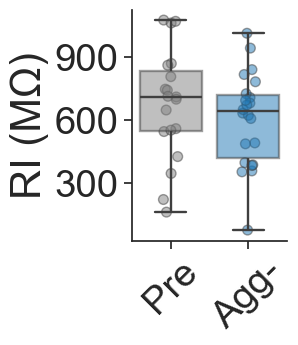

Behaviour_6hFD
Agg-    22
Pre     14
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     10
Name: ID_mouse, dtype: int64
sPSC_frequency ('Pre', 'Agg-') 167.0 0.6850183617449476
Behaviour_6hFD
Agg-    1.441626
Pre     1.804592
Name: sPSC_frequency, dtype: float64


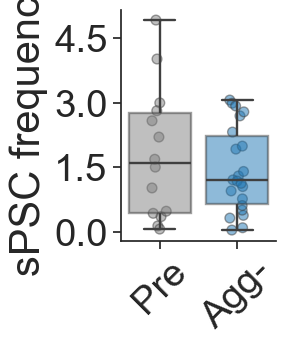

Behaviour_6hFD
Agg-    22
Pre     14
Name: count, dtype: int64
Behaviour_6hFD
Agg-     3
Pre     10
Name: ID_mouse, dtype: int64
sPSC_Amplitude(pA) ('Pre', 'Agg-') 228.0 0.01699031495579603
Behaviour_6hFD
Agg-    11.552273
Pre     13.619607
Name: sPSC_Amplitude(pA), dtype: float64


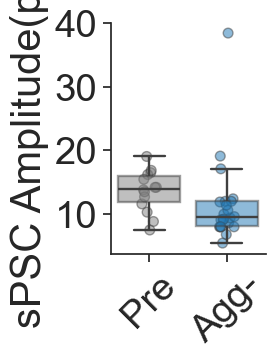

Behaviour_6hFD
Agg-    22
Pre     12
Name: count, dtype: int64
Behaviour_6hFD
Agg-    3
Pre     8
Name: ID_mouse, dtype: int64
sPSCs_Rise time ('Pre', 'Agg-') 130.0 0.9565103097049207
Behaviour_6hFD
Agg-    1.300000
Pre     1.016667
Name: sPSCs_Rise time, dtype: float64


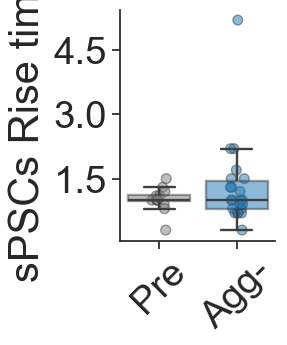

Behaviour_6hFD
Agg-    21
Pre     12
Name: count, dtype: int64
Behaviour_6hFD
Agg-    3
Pre     8
Name: ID_mouse, dtype: int64
sPSCs (decay) ('Pre', 'Agg-') 109.0 0.5368389141902543
Behaviour_6hFD
Agg-    9.619048
Pre     9.389108
Name: sPSCs (decay), dtype: float64


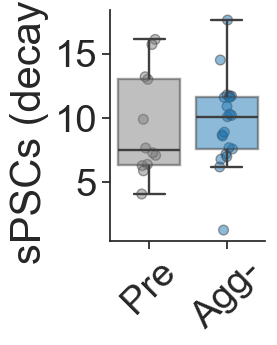

In [5]:
without_agg = ephys[ephys.Behaviour_6hFD != "Agg+"]

agg_minus = without_agg[(without_agg.Behaviour_6hFD == "Agg-")]
estrous_count = agg_minus.estrous_stage.value_counts()
print(estrous_count)
sampled_pres = []
for stage in estrous_count.index:
    sampled_pre = without_agg[
        (without_agg.Behaviour_6hFD == "Pre") & (without_agg.estrous_stage == stage)
    ].sample(n=int(estrous_count[stage]), random_state=42)
    sampled_pres.append(sampled_pre)
sampled_pres = pd.concat(sampled_pres, ignore_index=True)

sampled_pres_with_agg_minus = pd.concat(
    [sampled_pres, agg_minus], ignore_index=True, axis=0
)

preprocess_plot(
    sampled_pres_with_agg_minus,
    "Behaviour_6hFD",
    "pan",
    palette=["Gray", "Tab:blue"],
    order=["Pre", "Agg-"],
    plotting=True,
    identifier="without_agg_plus",
)

In [6]:
sampled_ephys.dropna(subset="I_zero_reclassified").groupby("pre_post_state")[
    "ID_mouse"
].nunique()

pre_post_state
Post     9
Pre     43
Name: ID_mouse, dtype: int64

I_zero_reclassified  non_silent  silent  All
pre_post_state                              
Post                         16      11   27
Pre                          97      39  136
All                         113      50  163
SignificanceResult(statistic=0.584817244611059, pvalue=0.25450095417767626)


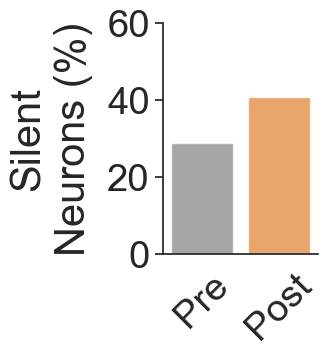

In [7]:
# % silent neurons
cols = ["silent"]

cat = ["Pre", "Agg+", "Agg-"]
sampled_ephys.loc[
    sampled_ephys["I_zero_reclassified"] != "silent", "I_zero_reclassified"
] = "non_silent"
silent_prop = proportion(
    sampled_ephys[sampled_ephys.Behaviour_6hFD.isin(cat)],
    "pre_post_state",
    "I_zero_reclassified",
    cols,
)
silent_prop["pre_post_state"] = pd.Categorical(
    silent_prop["pre_post_state"], ["Pre", "Post"]
)
silent_prop = silent_prop.sort_values(by=["pre_post_state"])


sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="pre_post_state",
    y="silent",
    order=["Pre", "Post"],
    palette=["gray", "Tab:orange"],
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent\nNeurons (%)", labelpad=10)
g.set_xticklabels(("Pre", "Post", r"Agg$^{–}$"), rotation=45)
plt.xlabel("")
plt.ylim(0, 60)
plt.title("")
sns.despine(bottom=False)
plt.savefig("output_figures/silent_prop_resampled.png", dpi=300, bbox_inches="tight")
g.tick_params(bottom=False)
# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/silent_proportion_sampled.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

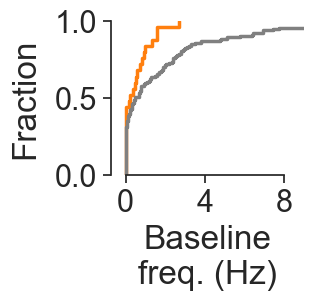

In [8]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=sampled_ephys,
    x="Firing_freq_(Hz)_I0",
    hue="pre_post_state",
    hue_order=["Pre", "Post"],
    palette=["gray", "tab:orange"],
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/ff_sampled.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [9]:
sampled_ephys_estrous.dropna(subset="I_zero_reclassified").groupby("pre_post_state")[
    "ID_mouse"
].nunique()

pre_post_state
Post     3
Pre     12
Name: ID_mouse, dtype: int64

I_zero_reclassified  non_silent  silent  All
pre_post_state                              
Post                          7       5   12
Pre                          32      15   47
All                          39      20   59
SignificanceResult(statistic=0.65625, pvalue=0.5179347568013896)


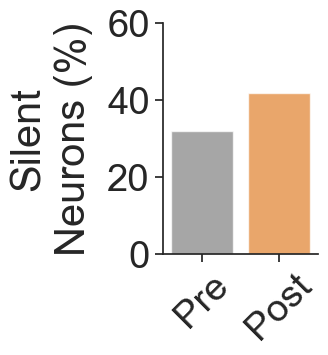

In [10]:
# % silent neurons
cols = ["silent"]


sampled_ephys_estrous.loc[
    sampled_ephys_estrous["I_zero_reclassified"] != "silent", "I_zero_reclassified"
] = "non_silent"
silent_prop = proportion(
    sampled_ephys_estrous, "pre_post_state", "I_zero_reclassified", cols
)
silent_prop["pre_post_state"] = pd.Categorical(
    silent_prop["pre_post_state"], ["Pre", "Post"]
)
silent_prop = silent_prop.sort_values(by=["pre_post_state"])


sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="pre_post_state",
    y="silent",
    order=["Pre", "Post"],
    palette=["gray", "Tab:orange"],
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent\nNeurons (%)", labelpad=10)
g.set_xticklabels(("Pre", "Post"), rotation=45)
plt.xlabel("")
plt.ylim(0, 60)
plt.title("")
sns.despine(bottom=False)
plt.savefig(
    "output_figures/silent_prop_estrous_controled.png", dpi=300, bbox_inches="tight"
)
# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/silent_proportion_estrous_sampled_D.pdf',
#                     dpi=300,bbox_inches='tight', transparent=True)

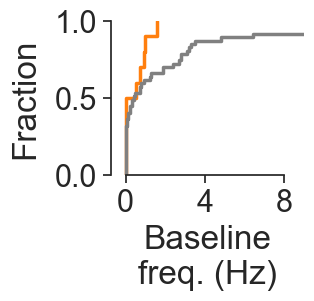

In [11]:
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=sampled_ephys_estrous,
    x="Firing_freq_(Hz)_I0",
    hue="pre_post_state",
    hue_order=["Pre", "Post"],
    palette=["gray", "tab:orange"],
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/ff_sampled_D.pdf',
#                     dpi=300,bbox_inches='tight', transparent=True)

I_zero_reclassified  non_silent  silent  All
Behaviour_6hFD                              
Agg-                         18       4   22
Pre                          16       6   22
All                          34      10   44
SignificanceResult(statistic=1.6875, pvalue=0.7205127812047835)


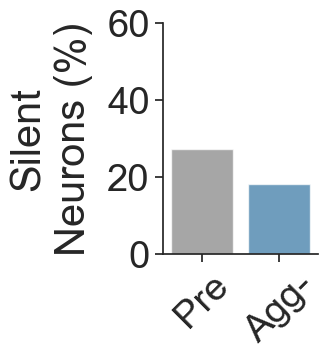

In [12]:
# % silent neurons
cols = ["silent"]


sampled_pres_with_agg_minus.loc[
    sampled_pres_with_agg_minus["I_zero_reclassified"] != "silent",
    "I_zero_reclassified",
] = "non_silent"
silent_prop = proportion(
    sampled_pres_with_agg_minus, "Behaviour_6hFD", "I_zero_reclassified", cols
)
silent_prop["Behaviour_6hFD"] = pd.Categorical(
    silent_prop["Behaviour_6hFD"], ["Pre", "Agg-"]
)
silent_prop = silent_prop.sort_values(by=["Behaviour_6hFD"])


sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "Agg-"],
    palette=["gray", "Tab:blue"],
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent\nNeurons (%)", labelpad=10)
g.set_xticklabels(("Pre", "Agg-"), rotation=45)
plt.xlabel("")
plt.ylim(0, 60)
plt.title("")
sns.despine(bottom=False)


plt.savefig(
    f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_17/linked_figure_S17/silent_prportion_without_aggression.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

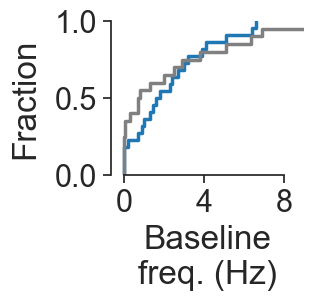

In [13]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=sampled_pres_with_agg_minus,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    hue_order=["Pre", "Agg-"],
    palette=["gray", "tab:blue"],
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_17/linked_figure_S17/ff_sampled_without_aggression.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [22]:
ramp_path = "ramps_all.csv"
import os

if os.path.exists(ramp_path):
    df_state = pd.read_csv(ramp_path)

In [23]:
states = [
    "Pre",
    "Agg+",
    "Agg-",
    "NPY 10nM",
    "NPY 100nM",
    "NPY Antag",
    "NPY1R",
    "NPY2R",
    "NPY-KD",
    "ZD7288",
]
df_all = process_df_state(df_state, states)

In [24]:
sampled_ephys.rename(columns={"experiment_day": "filename"}, inplace=True)
sampled_ephys["filename"] = sampled_ephys["filename"].str.upper()

df_all["filename"] = df_all["filename"].str.replace(".xlsx", "").str.upper()

combined_df = df_all.merge(sampled_ephys, on="filename", how="inner")

In [25]:
test_df = df_all.merge(sampled_ephys, on="filename", how="inner")
test_df = test_df[test_df["state_x"] == "Pre"]
test_df.loc[test_df["estrous_stage"] == "P<E", "estrous_stage"] = "E"
print(test_df[test_df["estrous_stage"].isna()].filename.unique())
print(test_df[~test_df["estrous_stage"].isin(["P", "E", "M", "D"])].filename.unique())

[]
['S1C1 23112023']


In [26]:
combined_df.groupby("pre_post_state")["filename"].nunique()

pre_post_state
Post    21
Pre     36
Name: filename, dtype: int64

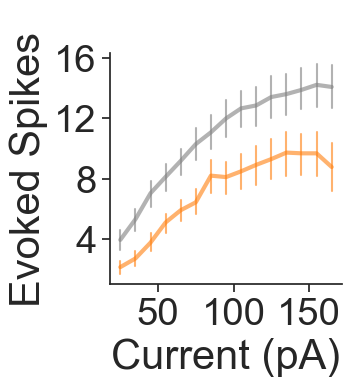

In [27]:
prop = "num_spike"


result_df = test_interaction_pvalues(
    combined_df,
    prop,
    [("Pre", "Post")],
    state_col="pre_post_state",
    group_var="filename",
    correction=True,
)

sns.set(font_scale=2.5)
sns.set_style("ticks")

fig, ax = plt.subplots(figsize=[3, 3])

palette = ["gray", "Tab:orange"]
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]
combined_df["pre_post_state"] = pd.Categorical(
    combined_df["pre_post_state"], ["Pre", "Post"]
)

sns.lineplot(
    data=combined_df,
    x="Injected",
    y=prop,
    hue="pre_post_state",
    palette=palette,
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
    sort=True,
)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked Spikes")
ax.set_xlabel("Current (pA)")
plt.title("")
# plt.ylim(0,20)
plt.title(" ", pad=10)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(bottom=False)

plot_significance_bars_shifted(
    ax,
    combined_df,
    result_df,
    [("Pre", "Post")],
    palette,
    base_y=1.2,
    y_shift=0,
    state_col="pre_post_state",
)

# plt.savefig(f'output_figures/{prop}_resampled.png',dpi = 300, bbox_inches = 'tight')
# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/{prop}_sampled.pdf',
#                     dpi=300,bbox_inches='tight', transparent=True)

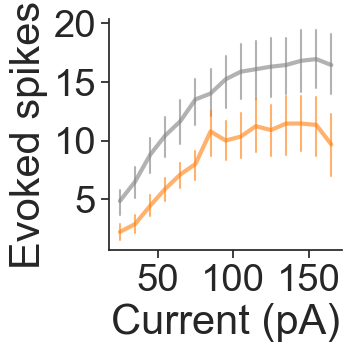

In [35]:
sampled_ephys_estrous.rename(columns={"experiment_day": "filename"}, inplace=True)
sampled_ephys_estrous["filename"] = sampled_ephys_estrous["filename"].str.upper()
combined_df = df_all.merge(sampled_ephys_estrous, on="filename", how="inner")
combined_df["pre_post_state"] = pd.Categorical(
    combined_df["pre_post_state"], ["Pre", "Post"]
)


result_df = test_interaction_pvalues(
    combined_df,
    prop,
    [("Pre", "Post")],
    state_col="pre_post_state",
    group_var="filename",
    correction=True,
)
sns.set(font_scale=2.5)
sns.set_style("ticks")

prop = "num_spike"

fig, ax = plt.subplots(figsize=[3, 3])

palette = ["gray", "Tab:orange"]
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(
    data=combined_df,
    x="Injected",
    y=prop,
    hue="pre_post_state",
    palette=palette,
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.title("")
# plt.ylim(0,32)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(bottom=False)

plot_significance_bars_shifted(
    ax,
    combined_df,
    result_df,
    [("Pre", "Post")],
    palette,
    base_y=1,
    y_shift=0,
    state_col="pre_post_state",
)


# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/{prop}_sampled_D.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [21]:
combined_df.groupby("pre_post_state")["ID_mouse"].nunique()

pre_post_state
Pre     4
Post    3
Name: ID_mouse, dtype: int64

In [126]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.mixedlm(
    f"{prop} ~ pre_post_state * Injected",
    combined_df,
    groups=combined_df["filename"],
).fit()

print(model.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          num_spike
No. Observations:          345              Method:                      REML     
No. Groups:                23               Scale:                       13.9898  
Min. group size:           15               Log-Likelihood:              -943.9243
Max. group size:           15               Converged:                   Yes      
Mean group size:           15.0                                                   
----------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                               4.857    2.417  2.009 0.044   0.120  9.595
pre_post_state[T.Post]                 -2.635    3.864 -0.682 0.495 -10.208  4.938
Injected[T.35]             

In [155]:
estrous_count

estrous_stage
P    12
M    10
Name: count, dtype: int64

12
10


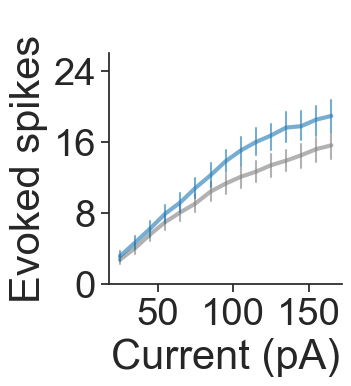

In [183]:
import random

ephys.rename(columns={"experiment_day": "filename"}, inplace=True)
ephys["filename"] = ephys["filename"].str.upper()
combined_df = df_all.merge(ephys, on="filename", how="inner")
combined_df = combined_df[combined_df["Behaviour_6hFD"] != "Agg+"]

sampled_excitability_pre = []
for estrous_stage in estrous_count.index:

    sampled_excitability_pre_ephys = combined_df[combined_df["Behaviour_6hFD"] == "Pre"]
    random.seed(4)
    filename = random.sample(
        sampled_excitability_pre_ephys["filename"].unique().tolist(),
        k=int(estrous_count[estrous_stage] * 1.5),
    )
    filtered_pre_excitablity = sampled_excitability_pre_ephys[
        sampled_excitability_pre_ephys["filename"].isin(filename)
    ]
    sampled_excitability_pre.append(filtered_pre_excitablity)

sampled_excitability_pre = pd.concat(sampled_excitability_pre, ignore_index=True)
sampled_pres_with_agg_minus_excitability = pd.concat(
    [sampled_excitability_pre, combined_df[combined_df["Behaviour_6hFD"] == "Agg-"]],
    ignore_index=True,
    axis=0,
)


sampled_pres_with_agg_minus_excitability["Behaviour_6hFD"] = pd.Categorical(
    sampled_pres_with_agg_minus_excitability["Behaviour_6hFD"], ["Pre", "Agg-"]
)


sns.set(font_scale=2.5)
sns.set_style("ticks")

prop = "num_spike"

fig, ax = plt.subplots(figsize=[3, 3])

palette = ["gray", "Tab:blue"]
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(
    data=sampled_pres_with_agg_minus_excitability,
    x="Injected",
    y=prop,
    hue="Behaviour_6hFD",
    palette=palette,
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
)

result_df = test_interaction_pvalues(
    sampled_pres_with_agg_minus_excitability,
    prop,
    [("Pre", "Agg-")],
    state_col="Behaviour_6hFD",
    group_var="filename",
    correction=True,
)

leg = ax.get_legend()
if leg:
    leg.remove()

plot_significance_bars_shifted(
    ax,
    sampled_pres_with_agg_minus_excitability,
    result_df,
    [("Pre", "Agg-")],
    palette,
    base_y=1.2,
    y_shift=0,
    state_col="Behaviour_6hFD",
)
ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.title("")
plt.ylim(0, 26)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(bottom=False)
plt.title(" ", pad=10)
plt.savefig(
    "output_figures/evoked_spikes_estrous_resampled.pdf", dpi=300, bbox_inches="tight"
)

In [187]:
sampled_pres_with_agg_minus_excitability.groupby("Behaviour_6hFD")["ID_mouse"].nunique()

Behaviour_6hFD
Pre     11
Agg-     3
Name: ID_mouse, dtype: int64

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Two-way ANOVA
model = smf.ols(
    "latency ~  C(pre_post_state) * Injected",
    data=combined_df[combined_df.estrous_stage == "P"],
).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

print(anova_results)

                                  sum_sq     df         F    PR(>F)
C(pre_post_state)           1.476745e+03    1.0  0.038816  0.843972
Injected                    2.154391e+06   14.0  4.044876  0.000003
C(pre_post_state):Injected  1.717553e+05   14.0  0.322471  0.990835
Residual                    9.549155e+06  251.0       NaN       NaN


In [154]:
combined_df.groupby("Behaviour_6hFD")["filename"].nunique()

Behaviour_6hFD
Pre      6
Agg-    19
Name: filename, dtype: int64